# **Shopping Behavior: Deciphering the Habits of Modern Trade**
Behavior is what we do repeatedly, day after day. In the world of commerce, these repetitions are the keys to understanding customer loyalty and business growth. This project explores the psychology behind every purchase, using data to bridge the gap between human feelings and commercial actions.

## **"Behind every transaction, there is a human emotion and a repeating pattern."**
Shopping behavior isn't just about buying; it’s a reflection of daily habits and psychological triggers that have evolved since the dawn of trade. In this project, I analyzed [https://www.kaggle.com/datasets/saadaliyaseen/shopping-behaviour-dataset/data] to decode these habitual patterns—turning human actions into actionable business insights.
Finding purchase patterns is a very important step in Business Intelligence. We will examine variables by grouping them together to systematically find patterns.

## **Dataset Structure & Variable Classification for Documentation**

| Variable | Name	| Type |	Measurement Scale |	Description (Myanmar) |
|----------|--------|------|----------------------|-----------------------|
| Age |	Quantitative |	Ratio/Continurous |	Age (at least 0 possible number) |
| Gender |	Qualitative |	Nominal |	Male / female |
| Item Purchased |	Qualitative |	Nominal |	Type of item purchased |
| Category |	Qualitative |	Nominal |	Item type group |
| Purchase Amount (USD) |	Quantitative |	Ratio |	Purchase amount |
| Location |	Qualitative |	Nominal |	Purchase location |
| Size |	Quantitative |	Ratio (if numeric) |	Item size (e.g. inches, cm) |
| Color |	Qualitative |	Nominal |	Color |
| Season |	Qualitative |	Nominal |	Season (e.g. Summer, Winter) |
| Review Rating |	Quantitative |	Ordinal (or Interval) |	User rating |
| Subscription Status |	Qualitative |	Nominal |	Subscribed/unsubscribed |
| Shipping Type |	Qualitative |	Nominal |	Shipping method (e.g. Express, Standard) |
| Discount Applied |	Qualitative |	Nominal |	Discount usage |
| Promo Code Used |	Qualitative |	Nominal |	Use of Promotion Code |
| Previous Purchases |	Quantitative |	Ratio |	Number of previous purchases |
| Payment Method |	Qualitative |	Nominal |	Payment method (e.g. Card, Cash) |
| Frequency of Purchases |	Quantitative/Ordinal |	Ratio or Ordinal |	Number of purchases or rating |


### (Demographic & Loyalty Patterns)

It looks at information such as age and gender of buyers and their purchasing behavior.

| Pattern you want to know | Variables to be used | Method/chart to be used |
|--------------------------|----------------------|-------------------------|
| Purchase amount by age | Age, Purchase Amount (USD) |	Grouping/Box Plot: Divide age into groups (e.g. 20-30, 31-40) and see which age group spends more on average with a Box Plot. |
| Usage by gender |	Gender, Purchase Amount (USD) |	Bar Chart: Compare the average purchase amount between men and women. |
| Customer loyalty | Subscription Status, Previous Purchases | Correlation/Pivot Table: Check if Subscription Status (Subscription/No Subscription) is correlated with the number of Previous Purchases and see how loyal the customer is. |

In [1]:
# preparing and importing required libraries 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load the dataset and checking information
dataset=pd.read_csv("C:/Users/KseO/Desktop/ML/shopping_behavior.csv")
# dataset.info()

In [2]:
dataset.drop(['Customer ID'], axis=1, inplace=True)
# print(dataset.head())

In [3]:
# Describe the dataset
dataset.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [4]:
# Encode the gender 
dataset['Gender'] = dataset['Gender'].map({'Male':0, 'Female':1})
print(dataset[['Gender']].head())

   Gender
0       0
1       0
2       0
3       0
4       0


#### **Calculating Average Purchase Amount by Gender**
We tested Male vs Female customers spending.
- Male customers → Average spending ≈ $60

- Female customers → Average spending ≈ $60

In a bar chart, the Male bar and the Female bar will be at almost the same height.

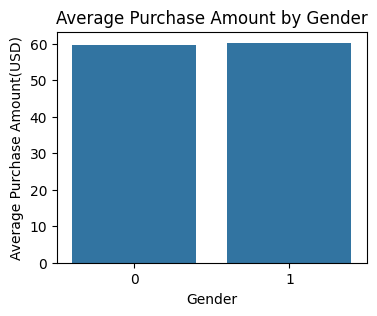

In [5]:
gender_spending = dataset.groupby('Gender')['Purchase Amount (USD)'].mean().reset_index()
plt.figure(figsize=(4,3))
sns.barplot(x='Gender', y='Purchase Amount (USD)', data=gender_spending)
plt.title('Average Purchase Amount by Gender')
plt.ylabel('Average Purchase Amount(USD)')
plt.show()

#### **Calculating the number of purchases by season and category**
It is written to visually display the Popularity (Purchase Count) of each Product Category by Season using a stacked bar chart.
- **Main objective:** Group the dataset by Season and Category, and calculate the number of samples (row count) in each group.

**This code is:**
- Which category sells best by season?

- Create a stacked bar chart that allows you to visually compare

- Useful for business decisions such as marketing, inventory planning, seasonal promotions, etc.


--- Seasonal Product Popularity (Count) ---
Category  Accessories  Clothing  Footwear  Outerwear
Season                                              
Fall              324       427       136         88
Spring            301       454       163         81
Summer            312       408       160         75
Winter            303       448       140         80


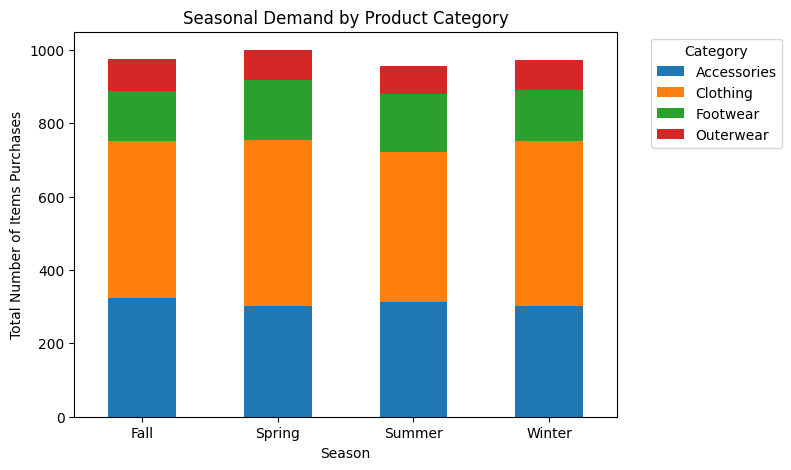

In [6]:
seasonal_category_sales = dataset.groupby(['Season', 'Category']).size().reset_index(name='Total_Purchases')
seasonal_pivot = seasonal_category_sales.pivot(index='Season', columns='Category', values='Total_Purchases').fillna(0)

print("\n--- Seasonal Product Popularity (Count) ---")
print(seasonal_pivot)

# Convert to Pivot Table format
seasonal_pivot.plot(kind='bar', stacked=True, figsize=(7,5))
plt.title('Seasonal Demand by Product Category')
plt.ylabel('Total Number of Items Purchases')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## **Analysis by Raw Counts**
First, we will calculate the total number of items purchased by each male and female in each category.

#### **Calculating the number of purchases by gender and category**
It is written to create a Raw Purchase Count Matrix by Gender and Product Category.
This syntax is written to display purchase counts by Gender (Male/Female) and Category (Accessories, Clothing, Footwear, Outerwear) in a dataset as a cross-tabulation table.
The purpose of this code is—
- Which category sells best by gender?

- To view customer behavior from a category-wise gender perspective

- Creating a base data matrix to create a visualization

In [7]:
# to view as table gender vs. category purchase pattern raw
gender_category_count = pd.crosstab(dataset['Gender'], dataset['Category'])

print("\n--- Gender vs. Category: Raw Purchase Counts ---")
print(gender_category_count)


--- Gender vs. Category: Raw Purchase Counts ---
Category  Accessories  Clothing  Footwear  Outerwear
Gender                                              
0                 848      1181       400        223
1                 392       556       199        101


#### **Calculate the percentage of each gender's total purchases by category (Normalize by 'index')**

In [8]:
# to view as table gender vs. category purchase pattern in percentage
gender_category_percent = pd.crosstab(dataset['Gender'], dataset['Category'], normalize='index') * 100

print("\n--- Gender vs. Category: Percentage Breakdown by Gender ---")

# Displaying the result more beautifully
print(gender_category_percent.round(2))


--- Gender vs. Category: Percentage Breakdown by Gender ---
Category  Accessories  Clothing  Footwear  Outerwear
Gender                                              
0               31.98     44.53     15.08       8.41
1               31.41     44.55     15.95       8.09


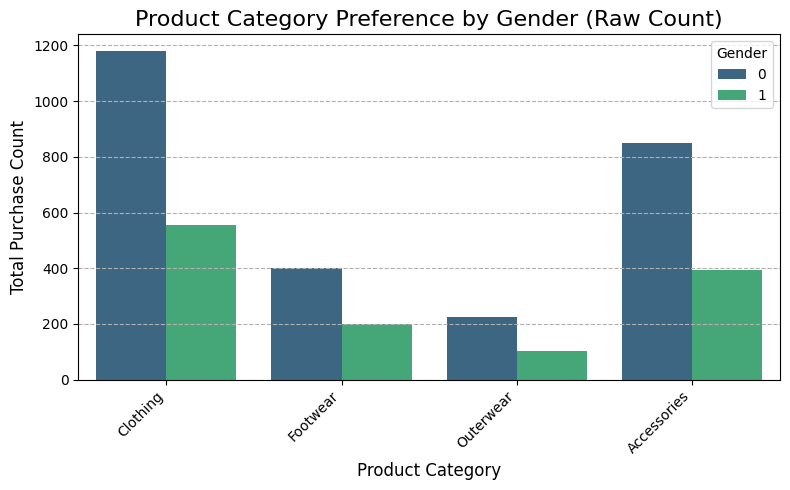

In [9]:
# Plotting the number of purchases by category by gender
plt.figure(figsize=(8, 5))
sns.countplot(data=dataset, x='Category', hue='Gender', palette='viridis')

plt.title('Product Category Preference by Gender (Raw Count)', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Purchase Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### **Grouping the Age Variable (Age Grouping)**
Since age is quantitative data, it first needs to be converted into age groups for easier analysis.

#### Setting age ranges. (Example: 18-30, 31-50, 51-65+)
The main purpose of this syntax is to group the Age column into bins and assign labels to the Age_Group column.

In [10]:
bins = [18, 30, 45, 60, 100]                  
labels = ['18-30 (Young)', '31-45 (Middle)', '46-60 (Senior)', '60+ (Retired)']

# Creating a new Age_Group Column
dataset['Age_Group'] = pd.cut(dataset['Age'], bins=bins, labels=labels, right=False)
print("Age Group organized done.")

Age Group organized done.


In [11]:
# Calculate the percentage of Payment Method by Age Group (normalize by index)
age_payment_crosstab = pd.crosstab(dataset['Age_Group'], dataset['Payment Method'], normalize='index') * 100

print("\n--- Age Group vs. Payment Method (Percentage) ---")
print(age_payment_crosstab.round(1))


--- Age Group vs. Payment Method (Percentage) ---
Payment Method  Bank Transfer  Cash  Credit Card  Debit Card  PayPal  Venmo
Age_Group                                                                  
18-30 (Young)            16.7  18.1         17.0        17.2    16.2   14.8
31-45 (Middle)           14.9  15.8         17.3        16.0    17.5   18.4
46-60 (Senior)           15.5  16.8         15.8        16.5    19.7   15.7
60+ (Retired)            15.9  18.5         19.3        15.5    15.1   15.7


<Figure size 1000x600 with 0 Axes>

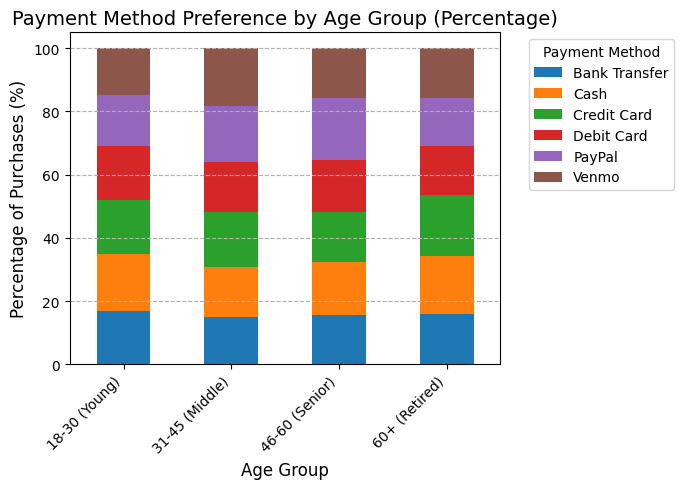

In [12]:
# Preparing the Table for Plotting
plot_data = age_payment_crosstab.copy()

# Plotting a Stacked Bar Chart
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', stacked=True, figsize=(7, 5))

plt.title('Payment Method Preference by Age Group (Percentage)', fontsize=14)
plt.ylabel('Percentage of Purchases (%)', fontsize=12)
plt.xlabel('Age Group', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### **To calculate the average, median, and total purchases for each Shipping Type,**  
**Sort the Shipping Type with the highest average at the top and display the output.**

Finding the relationship between Shipping Type and Purchase Amount (USD) is crucial for customer segmentation and pricing strategy. 
For example, 
this analysis can help you determine whether customers who choose the more expensive Express Shipping option tend to have a higher total purchase amount on average.

**Calculating the average volume by transportation**

- First, we will calculate the mean and median purchase amounts for each Shipping Type group.

- Calculating the median helps reduce the impact of outliers in the data.

    - Item Purchased, Category, Location, Size, and Season are key confounding factors that can help to explain the results.
  
    - The reasons for including these variables and the patterns they create are as follows:

In [13]:
# Calculating basic statistics of Purchase Amount by Shipping Type
shipping_spending_stats = dataset.groupby('Shipping Type')['Purchase Amount (USD)'].agg(
    Mean_Amount='mean',
    Median_Amount='median',
Total_Purchases='count'
).sort_values(by='Mean_Amount', ascending=False)

print("\n--- Shipping Type related Average Purchase Amount ---")
print(shipping_spending_stats.round(2))


--- Shipping Type related Average Purchase Amount ---
                Mean_Amount  Median_Amount  Total_Purchases
Shipping Type                                              
2-Day Shipping        60.73           60.0              627
Express               60.48           60.0              646
Free Shipping         60.41           62.0              675
Store Pickup          59.89           60.0              650
Next Day Air          58.63           58.5              648
Standard              58.46           58.0              654


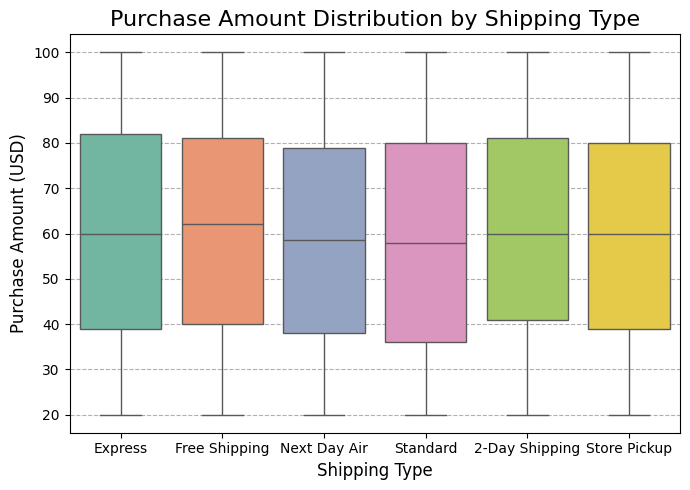

In [14]:
# Depicting the distribution using a box plot
plt.figure(figsize=(7, 5))
sns.boxplot(x='Shipping Type', y='Purchase Amount (USD)', data=dataset, hue='Shipping Type', palette='Set2', legend=False)

plt.title('Purchase Amount Distribution by Shipping Type', fontsize=16)
plt.xlabel('Shipping Type', fontsize=12)
plt.ylabel('Purchase Amount (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [15]:
# Calculate shipping type and average usage by location and category
multi_analysis = dataset.groupby(['Location', 'Category', 'Shipping Type'])['Purchase Amount (USD)'].mean().reset_index(name='Avg_Purchase_Amount')

print(multi_analysis)

# (Age_Group column must be created first)
gender_age_category_analysis = dataset.groupby(['Gender', 'Age_Group', 'Category'], observed=True).size().reset_index(name='Total_Count')
print(gender_age_category_analysis)

     Location     Category   Shipping Type  Avg_Purchase_Amount
0     Alabama  Accessories  2-Day Shipping            64.142857
1     Alabama  Accessories         Express            75.500000
2     Alabama  Accessories   Free Shipping            97.000000
3     Alabama  Accessories    Next Day Air            48.600000
4     Alabama  Accessories        Standard            51.000000
...       ...          ...             ...                  ...
1061  Wyoming    Outerwear         Express            79.500000
1062  Wyoming    Outerwear   Free Shipping            64.000000
1063  Wyoming    Outerwear    Next Day Air            40.000000
1064  Wyoming    Outerwear        Standard            57.000000
1065  Wyoming    Outerwear    Store Pickup            48.000000

[1066 rows x 4 columns]
    Gender       Age_Group     Category  Total_Count
0        0   18-30 (Young)  Accessories          191
1        0   18-30 (Young)     Clothing          280
2        0   18-30 (Young)     Footwear         

In [16]:
max_len = 25

categories = ['Accessories', 'Clothing', 'Footware', 'Outerware'] + [np.nan] * (max_len - 4)
colors = ['Beige', 'Black', 'Blue', 'Brown', 'Charcoal', 'Cyan', 'Gold', 'Gray', 'Green', 'Indigo', 'Larvender', 'Margenta', 'Maroon', 'Olive', 'Orange', 'Peach', 'Pink', 'Purple', 'Red', 'Silver', 'Teal', 'Turquoise', 'Violet', 'White', 'Yellow']
payments = ['Bank Transfer','Cash', 'Credit Card', 'Debit Card', 'PayPal', 'Venmo'] + [np.nan] * (max_len - 6)
frequencies = ['Annually', 'Bi-Weekly', 'Every 3 Months', 'Fortnightly','Monthly', 'Quarterly', 'Weekly'] + [np.nan] * (max_len - 7)

dataset = pd.DataFrame({
    'Category': categories,
    'Color': colors,
    'Payment': payments,
    'Frequency': frequencies
})
print("DataFrame structured successfuuly.")
print(dataset.head())

DataFrame structured successfuuly.
      Category     Color        Payment       Frequency
0  Accessories     Beige  Bank Transfer        Annually
1     Clothing     Black           Cash       Bi-Weekly
2     Footware      Blue    Credit Card  Every 3 Months
3    Outerware     Brown     Debit Card     Fortnightly
4          NaN  Charcoal         PayPal         Monthly


In [17]:
# Ordinal Encoding for Frequency
dataset_encoded = pd.get_dummies(dataset, columns=['Category', 'Color', 'Payment','Frequency'])

# Ordinal Encoding for Frequency
frequency_map = {
    'Annually': 0.083,
    'Every 3 Months': 0.33,
    'Quarterly': 0.33,
    'Monthly': 1,
    'Fortnightly': 2,
    'Bi-Weekly': 3.5,
    'Weekly': 7
}
dataset_encoded['Frequency'] = dataset['Frequency'].map(frequency_map)
# print(dataset_encoded)

In [18]:
# load required libraries 
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Loading Data
try:
    dataset=pd.read_csv("C:/Users/KseO/Desktop/ML/shopping_behavior.csv")
except FileNotFoundError:
        print("Dataset not found. Please ensure 'Shopping_Behavior.csv' is in the correct directory.")
exit()
contingency_table = pd.crosstab(dataset['Gender'], dataset['Subscription Status'])

# 2. Creating a Contingency Table
# Charting Gender as a Column, Subscription Status as a Row
print("--- Contingency Table (Observed Data) ---")
print(contingency_table)

# 3. Running the Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Statistical Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.6f}")

--- Contingency Table (Observed Data) ---
Subscription Status    No   Yes
Gender                         
Female               1248     0
Male                 1599  1053

--- Statistical Test Results ---
Chi-Square Statistic: 676.7944
P-Value: 0.000000


## **Loading Dependencies Libraries, Dataset to split for Machine Learning Model**

In [1]:
# Target and Features Separation
import pandas as pd
dataset=pd.read_csv("C:/Users/KseO/Desktop/ML/shopping_behavior.csv")
dataset.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [2]:
dataset.drop(['Customer ID'], axis=1, inplace=True)
y = dataset['Subscription Status']
X = pd.get_dummies(dataset.drop('Subscription Status', axis=1), drop_first=True)

In [3]:
# Splitting data into Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Preprocessing

In [4]:
# 1. Setting Target (y)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(dataset['Subscription Status'])

# 2. Setting Features (X) (very important)
# We need to remove both the target 'Subscription Status' and the 'Subscription_Encoded' that we just encoded.
# CIf the customer ID still exists, remove it at once.
X = dataset.drop(['Subscription Status', 'Subscription_Encoded'], axis=1, errors='ignore')

# 3. Converting text to numbers (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

In [5]:
from imblearn.pipeline import Pipeline as imbPipeline
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Build a Pipeline (Connect SMOTE and Model at once)
pipeline = imbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# 2. Shuffle the data using StratifiedKFold (this is very important)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Try Cross-Validation again.
cv_results = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print(f"Individual Fold Accuracies: {cv_results}")
print(f"Average CV Accuracy: {cv_results.mean():.4f}")

Individual Fold Accuracies: [0.80512821 0.83205128 0.82051282 0.81923077 0.83076923]
Average CV Accuracy: 0.8215


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Data Amount: {len(X_train)} | Testing Data Amount: {len(X_test)}")

Training Data Amount: 3120 | Testing Data Amount: 780


In [7]:
# # Predict the Trained Model

# 1. Fit the pipeline (this is important - you must fit the pipeline before running model.predict)
pipeline.fit(X_train, y_train)

# 2. Predict
y_pred = pipeline.predict(X_test)
print("Model Train Prediction is done successfully!")

Model Train Prediction is done successfully!


In [8]:
# Imagine a subscription prediction project
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Model Performance ---")
print(f"Accuracy Score: {accuracy:.4f}")


--- Model Performance ---
Accuracy Score: 0.8128


In [9]:
print("\nClassification Report (0=No Sub, 1=Yes Sub):")
print(classification_report(y_test, y_pred))


Classification Report (0=No Sub, 1=Yes Sub):
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       558
           1       0.62      0.88      0.73       222

    accuracy                           0.81       780
   macro avg       0.78      0.83      0.79       780
weighted avg       0.85      0.81      0.82       780



In [ ]:
# Building a Random Forest Model
# n_estimators: Number of Decision Trees to use
# from sklearn.ensemble import RandomForestRegressor

# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
# print("Random Forest Model is being start trained!...")

In [ ]:
# Training the Model with Training Data
# rf_model.fit(X_train, y_train)
# print("Trained Model Complete.")

In [ ]:
#import os
# print(os.listdir())

In [ ]:
# import joblib

# # 1. First, load the saved model and give it a variable name.
# loaded_pipeline = joblib.load('shopping_behavior_pipeline.pkl') 

# # 2. Now use that variable to predict.
# rf_predictions = loaded_pipeline.predict(X_test)

# print("Predictions are successful!")

In [ ]:
# Convert number to string using LabelEncoder
# y_pred_labels = le.inverse_transform(y_pred)

# # print(y_pred_labels)

In [ ]:
# comparing prediction: (y_pred) with Original result: (y_test)
# from sklearn.metrics import accuracy_score, classification_report

# accuracy = accuracy_score(y_test, y_pred)
# print(f'Model Accuracy: {accuracy * 100:.2f}%')

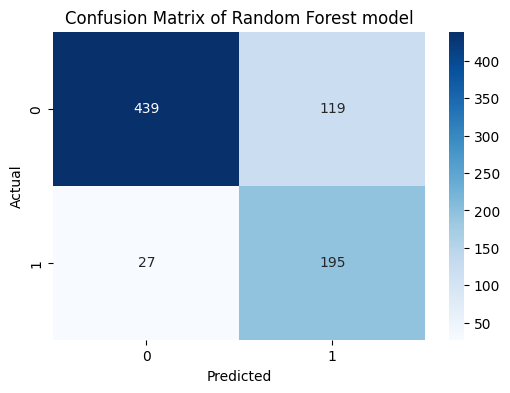

In [10]:
# Checking the model with Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Building the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visuallizing
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Random Forest model')
plt.show()

In [11]:
# Training a Random Forest Classifier (Model Interpretability ) 
# (We have to use a Classifier, because the Target is Yes/No (0/1))
from sklearn.ensemble import RandomForestClassifier

rf_model_importance = RandomForestClassifier(n_estimators=100, random_state=42)

In [12]:
# Training the Model with Training Data
rf_model_importance.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
# (Optional: Checking the accuracy of the model)
y_pred_imp = rf_model_importance.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_imp)
print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")

Random Forest Classifier Accuracy: 0.8205


In [14]:
# Getting the names of features
feature_names = X_train.columns

In [15]:
# Getting Feature Importances values
importances = rf_model_importance.feature_importances_

In [16]:
# Collecting Feature Names and Importance Values ​​into a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

In [17]:
# Sorting by Importance values ​​from highest to lowest
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Most Important Features ---")
print(feature_importance_df.head(10).round(4))


--- Top 10 Most Important Features ---
                   Feature  Importance
117    Promo Code Used_Yes      0.2133
116   Discount Applied_Yes      0.2122
1    Purchase Amount (USD)      0.0410
4              Gender_Male      0.0409
3       Previous Purchases      0.0402
0                      Age      0.0388
2            Review Rating      0.0333
81                  Size_M      0.0081
110          Season_Winter      0.0075
109          Season_Summer      0.0074


In [18]:
# Getting the Top 10 features
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance_df.head(10)
plt.figure(figsize=(7, 5))

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

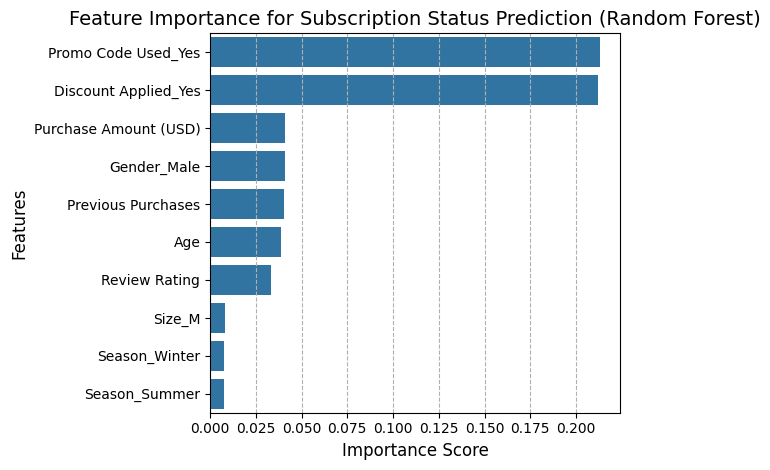

In [19]:
# Arrange the plot from least to most important
sns.barplot(x='Importance', y='Feature', data=top_features)

plt.title('Feature Importance for Subscription Status Prediction (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

In [20]:
# Calculating Training Accuracy
train_accuracy = accuracy_score(y_train, pipeline.predict(X_train))

In [21]:
#  Recalculate Testing Accuracy (to compare with previous results)
y_test_pred = pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f} (Previous score is 0.7987.)")

Training Accuracy: 0.8487
Testing Accuracy:  0.8128 (Previous score is 0.7987.)


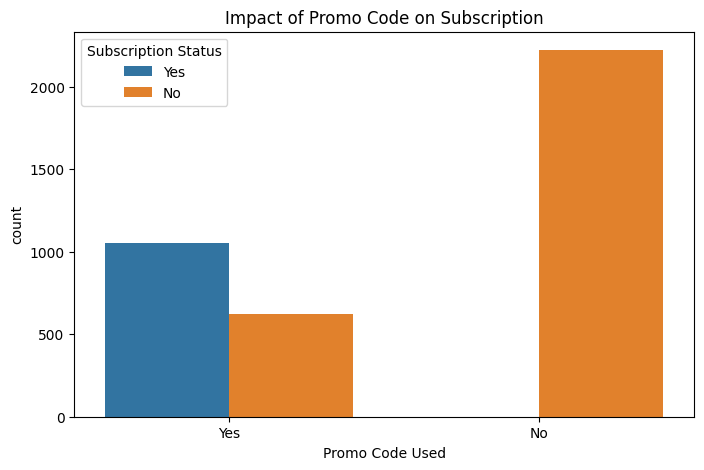

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compare how many subscribers are among those who used the promo code.
plt.figure(figsize=(8, 5))
sns.countplot(data=dataset, x='Promo Code Used', hue='Subscription Status')
plt.title('Impact of Promo Code on Subscription')
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler 
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

# Add GaussianNB to the Pipeline
nb_pipeline = imbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()), # Naive Bayes often requires good scaling
    ('classifier', GaussianNB())
])

# CV checking
nb_scores = cross_val_score(nb_pipeline, X, y, cv=cv)
print(f"Naive Bayes CV Accuracy: {nb_scores.mean():.4f}")

Naive Bayes CV Accuracy: 0.8390


In [24]:
from sklearn.metrics import classification_report

# 1. Training the Model (Fit the pipeline)
# X_train and y_train must have been defined in previous cells.
nb_pipeline.fit(X_train, y_train)

# 2. Making predictions using test data
y_pred_nb = nb_pipeline.predict(X_test)

# 3. Printing the Classification Report
print("--- Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

--- Naive Bayes Classification Report ---
              precision    recall  f1-score   support

          No       0.99      0.76      0.86       558
         Yes       0.62      0.99      0.76       222

    accuracy                           0.82       780
   macro avg       0.81      0.87      0.81       780
weighted avg       0.89      0.82      0.83       780



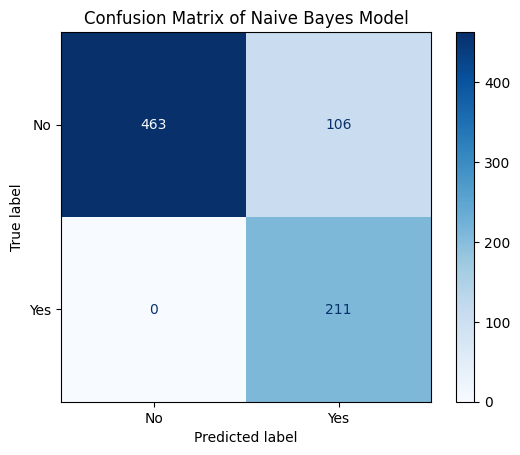

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Fit the Model and Predict
nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

# 3. Calculating the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)

# 4. Description (I will edit this section a little)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues') 

plt.title('Confusion Matrix of Naive Bayes Model') 
plt.show() 

In [26]:
from sklearn.svm import SVC

# Building an SVM Pipeline
svm_pipeline = imbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()), # Scaling is essential for SVM
    ('classifier', SVC(kernel='linear', random_state=42))
])

# CV check
svm_scores = cross_val_score(svm_pipeline, X, y, cv=cv)

print(f"Linear SVM CV Accuracy: {svm_scores.mean():.4f}")

Linear SVM CV Accuracy: 0.8305


In [27]:
from sklearn.metrics import classification_report

# 1. Training the Model (Fit the pipeline)
# X_train and y_train must have been defined in previous cells.
svm_pipeline.fit(X_train, y_train)

# 2. Making predictions using test data
y_pred_svm = svm_pipeline.predict(X_test)

# 3. Printing the Classification Report
print("--- SVM Classification Report ---")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

--- SVM Classification Report ---
              precision    recall  f1-score   support

          No       0.97      0.83      0.90       569
         Yes       0.67      0.93      0.78       211

    accuracy                           0.86       780
   macro avg       0.82      0.88      0.84       780
weighted avg       0.89      0.86      0.87       780



In [28]:
from sklearn.neighbors import KNeighborsClassifier

# Building a KNN Pipeline
knn_pipeline = imbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()), # KNN is distance-based and scaling is essential.
    ('classifier', KNeighborsClassifier(n_neighbors=5)) # Typically, the closest 5 people will be asked to watch.
])

# CV check
knn_scores = cross_val_score(knn_pipeline, X, y, cv=cv)

print(f"KNN CV Accuracy: {knn_scores.mean():.4f}")

KNN CV Accuracy: 0.7249


In [29]:
from sklearn.metrics import classification_report

# 1. Training the Model (Fit the pipeline)
# X_train and y_train must have been defined in previous cells.
knn_pipeline.fit(X_train, y_train)

# 2. Making predictions using test data
y_pred_knn = knn_pipeline.predict(X_test)

# 3. Printing the Classification Report
print("--- KNN Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

--- KNN Classification Report ---
              precision    recall  f1-score   support

          No       0.77      0.91      0.83       569
         Yes       0.52      0.26      0.34       211

    accuracy                           0.74       780
   macro avg       0.65      0.58      0.59       780
weighted avg       0.70      0.74      0.70       780



In [30]:
import joblib
from imblearn.pipeline import Pipeline as imbPipeline

# 1. Chaining (linking processes)
# Here everything is stored in a variable called 'final_chain_model'
final_chain_model = imbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', GaussianNB()) 
])

# 2. Training the Model
final_chain_model.fit(X, y)

# 3. Save the Model (All Variables)
# Here, the variable 'final_chain_model' has been converted to a file.
joblib.dump(final_chain_model, "shopping_behavior_pipeline.pkl")

print("Pipeline (Model + Preprocessing) has been saved successfully!")

Pipeline (Model + Preprocessing) has been saved successfully!


In [31]:
import joblib
import pandas as pd

# Recalling the model and putting it into a variable
loaded_pipeline = joblib.load('shopping_behavior_pipeline.pkl')

print("Model loaded successfully!")

Model loaded successfully!


In [32]:
# Example - Let's say 2 new customers arrive.
new_data = X_test.head(2) # Taking some data from X_test for testing

# or create a new data manually
# (Note - Column names must be in the same order)

In [33]:
# Making predictions
predictions = loaded_pipeline.predict(new_data)

# Convert the answer back to a human-readable label (Yes/No)
# le is the LabelEncoder you used before
predicted_labels = le.inverse_transform(predictions)

print(f"Predictions for New Customers: {predicted_labels}")

Predictions for New Customers: ['No' 'No']


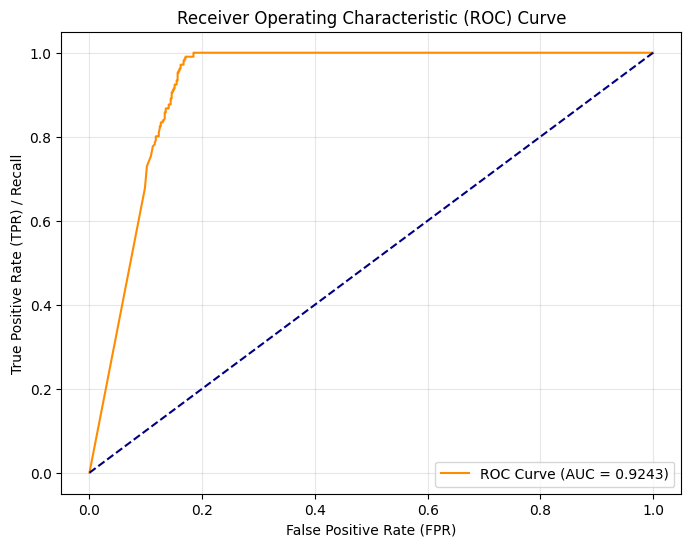

Model AUC Score: 0.9243


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calculating Probability
# [:, 1] This means taking the probability of Positive Class (Yes/Subscriber)
y_probs = final_chain_model.predict_proba(X_test)[:, 1]

# 2. Calculating AUC Score
auc_score = roc_auc_score(y_test, y_probs)

# 3. Extracting the necessary information for the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 4. Visualization
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # / (Random line)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Model AUC Score: {auc_score:.4f}")

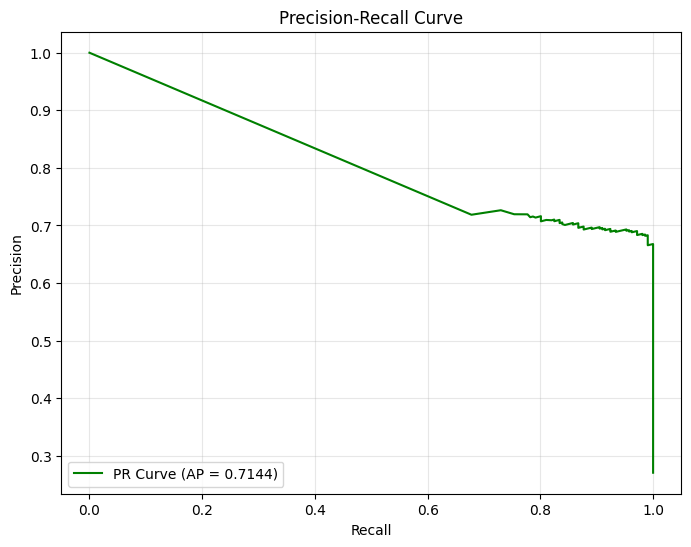

In [35]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculating Average Precision Score
ap_score = average_precision_score(y_test, y_probs)

# Extraction for PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', label=f'PR Curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()